<a href="https://colab.research.google.com/github/guptadevanshu845-star/DS_Project/blob/main/Credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Credit card Fradulant dectection**

Step-1: import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

Step-2: load Data

In [3]:
df = pd.read_csv('/content/credit_risk_dataset.csv.zip')

print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
print(df.info())
print('\n── Nulls ──')
print(df.isnull().sum())
print('\n── Target distribution ──')
print(df['loan_status'].value_counts(normalize=True).round(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None

── Nulls ──
person_age   

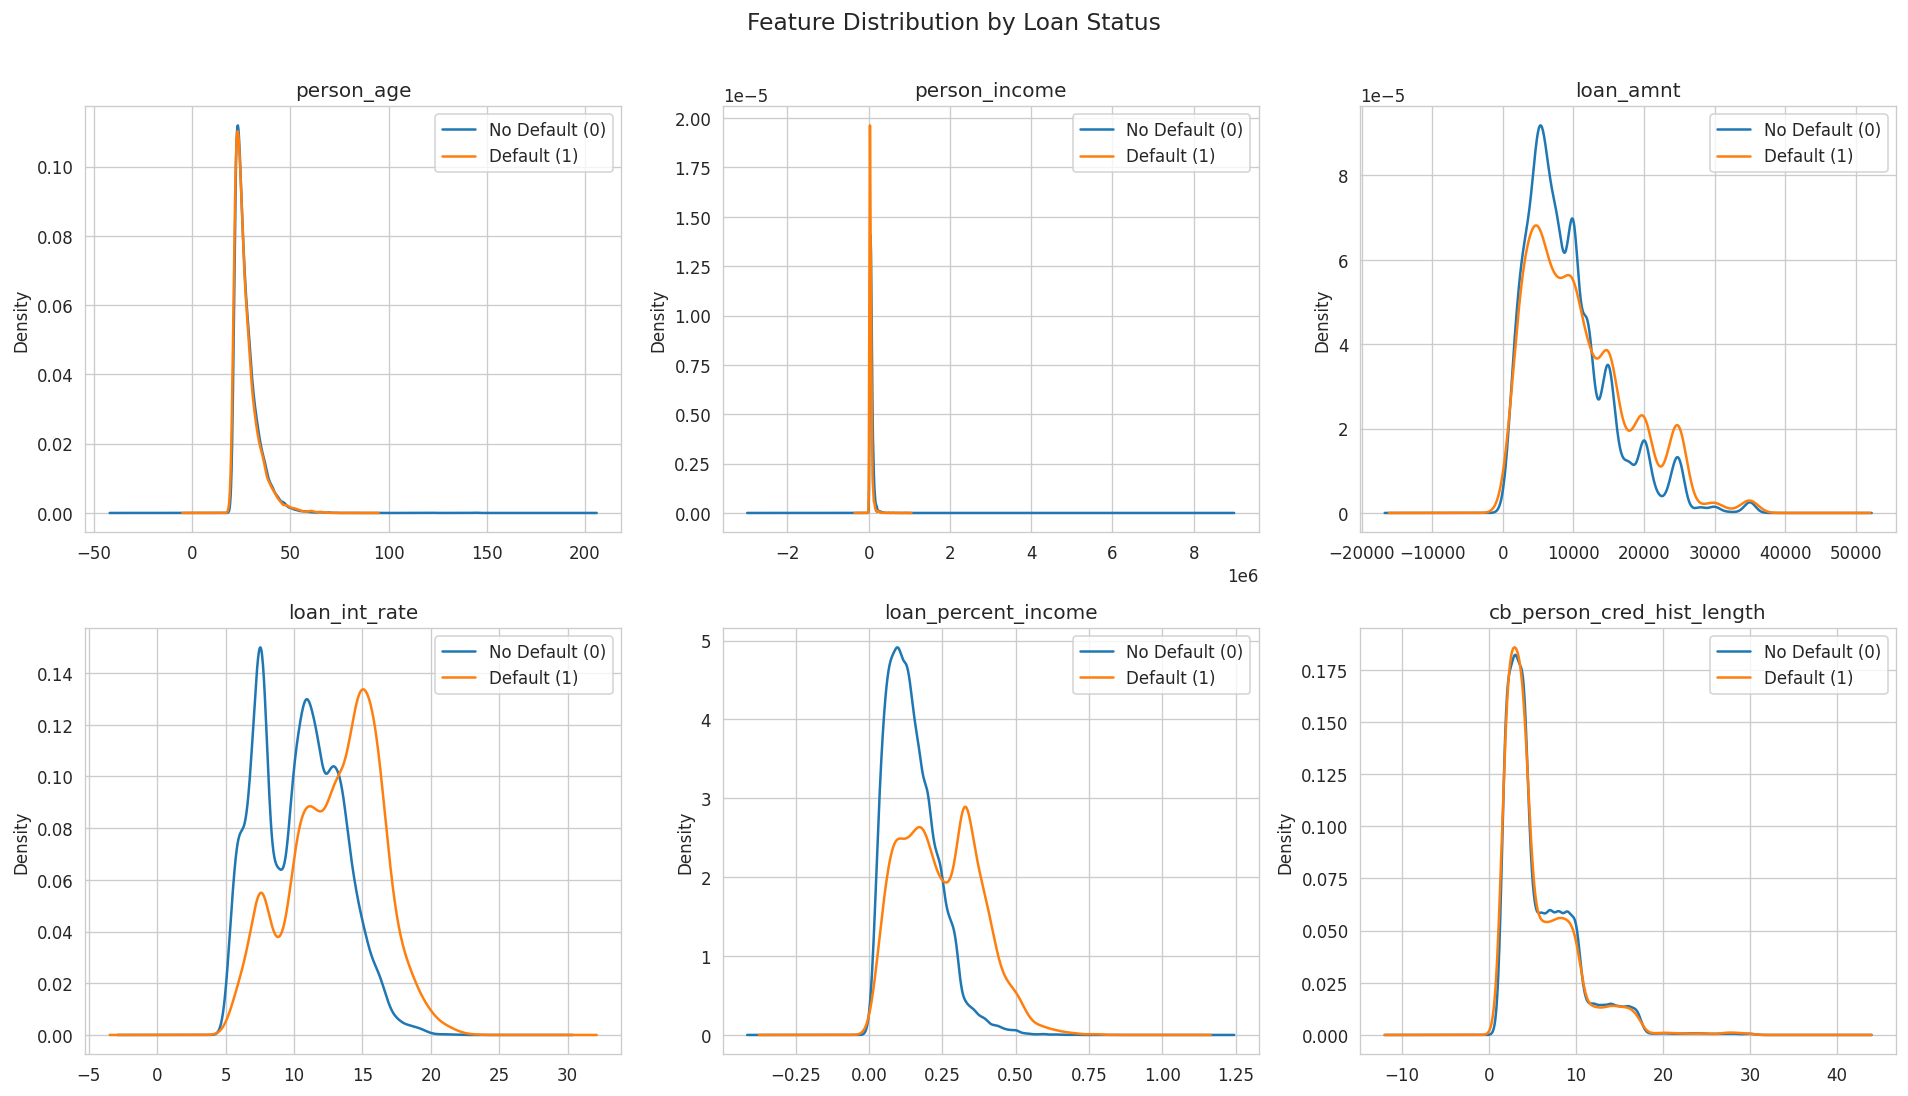

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate',
            'loan_percent_income', 'cb_person_cred_hist_length']

for ax, col in zip(axes.flat, num_cols):
    df.groupby('loan_status')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
    ax.legend(['No Default (0)', 'Default (1)'])

plt.suptitle('Feature Distribution by Loan Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

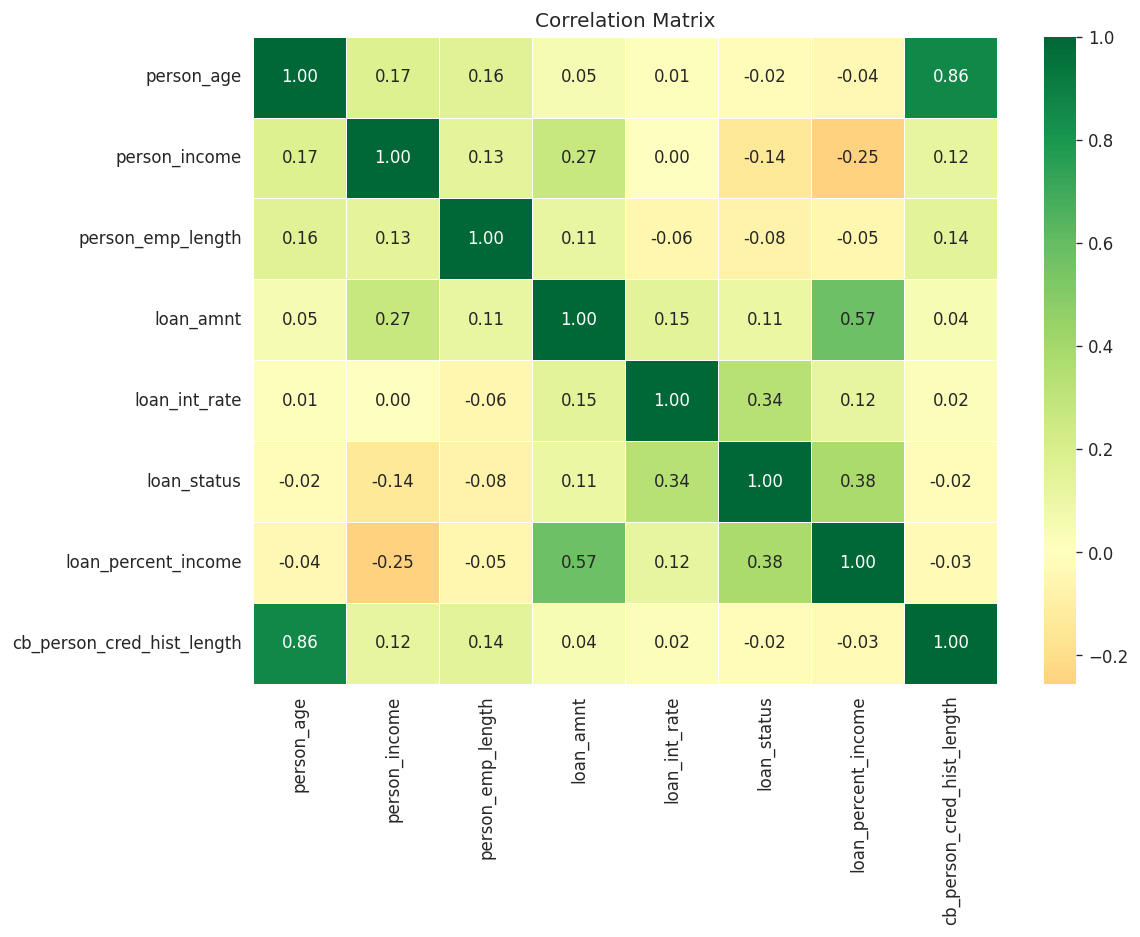

In [8]:
# Correlation heatmap
corr = df.select_dtypes('number').corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [9]:
df_fe = df.copy()

# ── Engineered features ────────────────────────────────────────────────────

# 1. Debt-to-income (loan_amnt / person_income) — higher = riskier
df_fe['debt_to_income'] = df_fe['loan_amnt'] / (df_fe['person_income'] + 1)

# 2. Interest burden (int_rate × loan_amnt) — total cost proxy
df_fe['interest_burden'] = df_fe['loan_int_rate'] * df_fe['loan_amnt'] / 100

# 3. Income per year of employment
df_fe['income_per_emp_yr'] = df_fe['person_income'] / (df_fe['person_emp_length'] + 1)

# 4. Young + short history flag (high-risk profile)
df_fe['young_low_hist'] = ((df_fe['person_age'] < 27) &
                            (df_fe['cb_person_cred_hist_length'] < 3)).astype(int)

# 5. Log-transform skewed income
df_fe['log_income'] = np.log1p(df_fe['person_income'])

# 6. Encode categorical columns
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
df_fe = pd.get_dummies(df_fe, columns=cat_cols, drop_first=True)

print('Shape after FE:', df_fe.shape)
df_fe.head(2)

Shape after FE: (32581, 28)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,debt_to_income,interest_burden,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,0.593210,5607.0,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,0.104156,111.4,...,False,False,False,True,False,False,False,False,False,False


In [10]:
TARGET = 'loan_status'
DROP_COLS = ['person_income']  # replaced by log_income

X = df_fe.drop(columns=[TARGET] + DROP_COLS)
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Default rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}')

Train: (26064, 26) | Test: (6517, 26)
Default rate — Train: 0.218 | Test: 0.218


In [11]:
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=0.1,                  # L2 regularization
        class_weight='balanced',# handles class imbalance
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

# Cross-validated ROC-AUC
cv_scores = cross_val_score(
    pipe, X_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f'CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV ROC-AUC: 0.8796 ± 0.0025


In [12]:
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred = pipe.predict(X_test)

roc_auc = roc_auc_score(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)
print(f'Test ROC-AUC : {roc_auc:.4f}')
print(f'Avg Precision: {avg_prec:.4f}')
print('\n── Classification Report ──')
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

Test ROC-AUC : 0.8782
Avg Precision: 0.7327

── Classification Report ──
              precision    recall  f1-score   support

  No Default       0.93      0.82      0.88      5095
     Default       0.56      0.79      0.65      1422

    accuracy                           0.82      6517
   macro avg       0.75      0.81      0.76      6517
weighted avg       0.85      0.82      0.83      6517



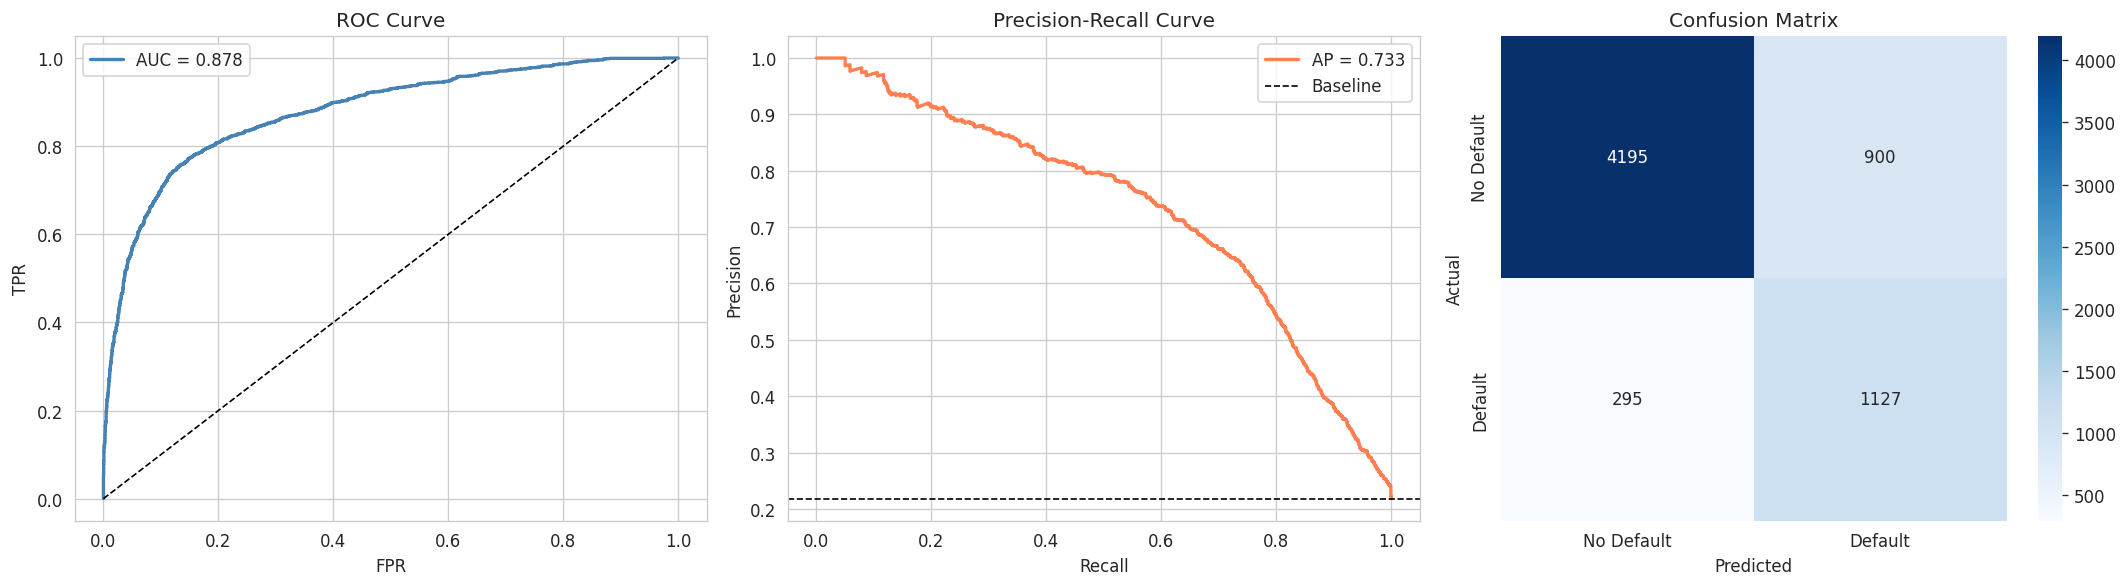

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(title='ROC Curve', xlabel='FPR', ylabel='TPR')
axes[0].legend()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, color='coral', lw=2, label=f'AP = {avg_prec:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', lw=1, label='Baseline')
axes[1].set(title='Precision-Recall Curve', xlabel='Recall', ylabel='Precision')
axes[1].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
axes[2].set(title='Confusion Matrix', ylabel='Actual', xlabel='Predicted')

plt.tight_layout()
plt.show()

KS Statistic : 0.6240  (>0.20 is acceptable for credit)
p-value      : 2.3369e-321


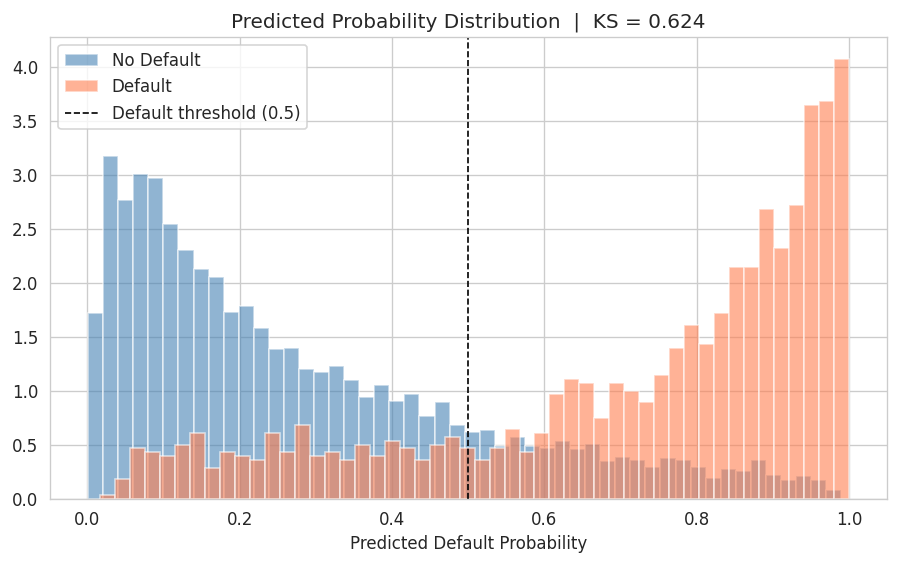

In [15]:
# KS = max separation between CDFs of default vs non-default score distributions
from scipy.stats import ks_2samp

scores_default    = y_prob[y_test == 1]
scores_no_default = y_prob[y_test == 0]

ks_stat, ks_pval = ks_2samp(scores_default, scores_no_default)
print(f'KS Statistic : {ks_stat:.4f}  (>0.20 is acceptable for credit)')
print(f'p-value      : {ks_pval:.4e}')

# Visual
plt.figure(figsize=(9, 5))
plt.hist(scores_no_default, bins=50, alpha=0.6, label='No Default', color='steelblue', density=True)
plt.hist(scores_default,    bins=50, alpha=0.6, label='Default',    color='coral',    density=True)
plt.axvline(0.5, color='k', linestyle='--', lw=1, label='Default threshold (0.5)')
plt.title(f'Predicted Probability Distribution  |  KS = {ks_stat:.3f}')
plt.xlabel('Predicted Default Probability')
plt.legend()
plt.show()

Optimal threshold: 0.62  |  Best F1 (default): 0.6843


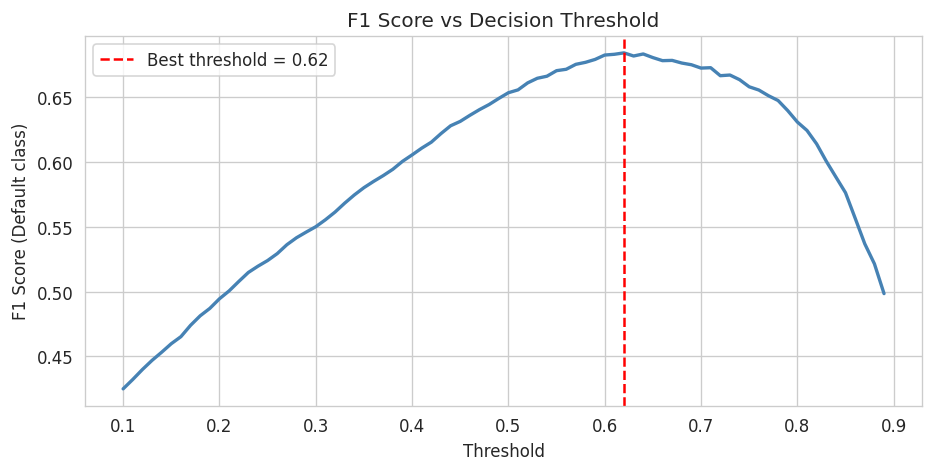


── Classification Report at Optimal Threshold ──
              precision    recall  f1-score   support

  No Default       0.92      0.89      0.90      5095
     Default       0.65      0.73      0.68      1422

    accuracy                           0.85      6517
   macro avg       0.78      0.81      0.79      6517
weighted avg       0.86      0.85      0.86      6517



In [16]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int), pos_label=1) for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1     = max(f1_scores)
print(f'Optimal threshold: {best_thresh:.2f}  |  Best F1 (default): {best_f1:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, color='steelblue', lw=2)
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best threshold = {best_thresh:.2f}')
plt.title('F1 Score vs Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score (Default class)')
plt.legend()
plt.show()

# Final report at optimal threshold
y_pred_opt = (y_prob >= best_thresh).astype(int)
print('\n── Classification Report at Optimal Threshold ──')
print(classification_report(y_test, y_pred_opt, target_names=['No Default', 'Default']))

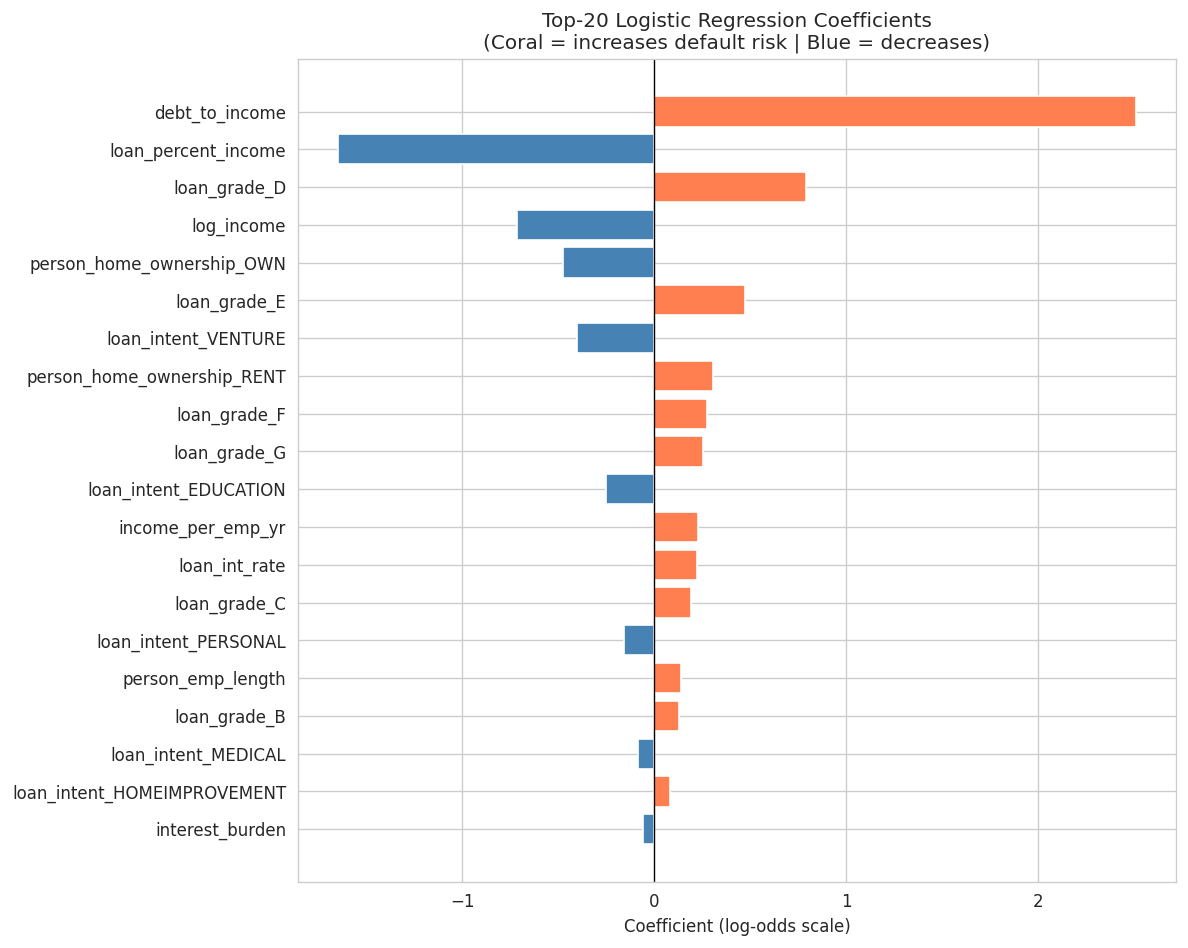

                    Feature  Coefficient
             debt_to_income     2.510875
        loan_percent_income    -1.649217
               loan_grade_D     0.791192
                 log_income    -0.717978
  person_home_ownership_OWN    -0.477716
               loan_grade_E     0.470585
        loan_intent_VENTURE    -0.400641
 person_home_ownership_RENT     0.303831
               loan_grade_F     0.273532
               loan_grade_G     0.256106
      loan_intent_EDUCATION    -0.252953
          income_per_emp_yr     0.228730
              loan_int_rate     0.221304
               loan_grade_C     0.189840
       loan_intent_PERSONAL    -0.156735
          person_emp_length     0.137206
               loan_grade_B     0.127255
        loan_intent_MEDICAL    -0.083353
loan_intent_HOMEIMPROVEMENT     0.080484
            interest_burden    -0.057042


In [17]:
# Extract coefficients from the pipeline
lr_model   = pipe.named_steps['lr']
feat_names = X_train.columns.tolist()

coef_df = pd.DataFrame({
    'Feature'    : feat_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

plt.figure(figsize=(10, 8))
colors = ['coral' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', lw=0.8)
plt.title('Top-20 Logistic Regression Coefficients\n(Coral = increases default risk | Blue = decreases)', fontsize=12)
plt.xlabel('Coefficient (log-odds scale)')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

key risk
loan_grade_* -- grade G/F higest default coefficient
loan_int_rate --higher ->higher risk
